In [8]:
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Paramètres d'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Toutes les bibliothèques sont importées avec succès.")

✅ Toutes les bibliothèques sont importées avec succès.


In [9]:
# ============================================================
# 02_load_dataset
# ============================================================

# Chargement du dataset via chemin relatif
df = pd.read_excel("DryBeanDataset/Dry_Bean_Dataset.xlsx")

# Preuve de la source
print("Source : UCI Machine Learning Repository")
print("URL : https://archive.ics.uci.edu/dataset/602/dry+bean+dataset")
print()

# Dimensions du dataset
print(f"Taille du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print()

# Types des colonnes
print("Types des colonnes :")
print(df.dtypes)
print()

# Distribution des 7 classes
print("Distribution des classes :")
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

Source : UCI Machine Learning Repository
URL : https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

Taille du dataset : 13611 lignes × 17 colonnes

Types des colonnes :
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object

Distribution des classes :
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Class
DERMASON    26.05 %
SIRA        19.37 %
SEKER       14.89 %
HOROZ       14.17 %
CALI        11.98 %
BARBUNYA     9.71 %
BOMBAY       3.84 %
Name: proportion, dtype: st

In [10]:
# ============================================================
# 03_problem_understanding
# ============================================================

print("""
PROBLÉMATIQUE
=============
Comment prédire automatiquement la variété d'un grain de haricot sec
à partir de ses mesures morphologiques extraites d'images ?

CONTEXTE
========
Les haricots secs sont l'une des cultures légumineuses les plus consommées
au monde. Leur classification manuelle est coûteuse et sujette aux erreurs.
Ce projet applique des méthodes de Data Mining pour automatiser cette
classification à partir de 16 caractéristiques morphologiques (surface,
périmètre, forme, compacité, etc.).

TYPE DE TÂCHE
=============
- Tâche          : Classification supervisée multiclasses
- Variable cible : Class (7 variétés de haricots)
- Variables      : 16 features numériques morphologiques
- Algorithmes    : Logistic Regression, KNN, Decision Tree, Random Forest
""")


PROBLÉMATIQUE
Comment prédire automatiquement la variété d'un grain de haricot sec
à partir de ses mesures morphologiques extraites d'images ?

CONTEXTE
Les haricots secs sont l'une des cultures légumineuses les plus consommées
au monde. Leur classification manuelle est coûteuse et sujette aux erreurs.
Ce projet applique des méthodes de Data Mining pour automatiser cette
classification à partir de 16 caractéristiques morphologiques (surface,
périmètre, forme, compacité, etc.).

TYPE DE TÂCHE
- Tâche          : Classification supervisée multiclasses
- Variable cible : Class (7 variétés de haricots)
- Variables      : 16 features numériques morphologiques
- Algorithmes    : Logistic Regression, KNN, Decision Tree, Random Forest



In [11]:
# ============================================================
# 04_dataset_description
# ============================================================

print("=== DESCRIPTION DES VARIABLES ===\n")

description = {
    "Area"           : "Surface de la zone du grain (pixels)",
    "Perimeter"      : "Périmètre du contour du grain",
    "MajorAxisLength": "Longueur du grand axe de l'ellipse englobante",
    "MinorAxisLength": "Longueur du petit axe de l'ellipse englobante",
    "AspectRation"   : "Ratio grand axe / petit axe",
    "Eccentricity"   : "Excentricité de l'ellipse (0=cercle, 1=ligne)",
    "ConvexArea"     : "Surface de l'enveloppe convexe du grain",
    "EquivDiameter"  : "Diamètre d'un cercle de même surface",
    "Extent"         : "Ratio surface grain / surface boîte englobante",
    "Solidity"       : "Ratio surface grain / surface convexe",
    "roundness"      : "Circularité du grain (proche de 1 = rond)",
    "Compactness"    : "Compacité relative du grain",
    "ShapeFactor1"   : "Facteur de forme 1 (rapport axes/surface)",
    "ShapeFactor2"   : "Facteur de forme 2",
    "ShapeFactor3"   : "Facteur de forme 3 (circularité normalisée)",
    "ShapeFactor4"   : "Facteur de forme 4",
    "Class"          : "✅ CIBLE — Variété du haricot (7 classes)"
}

for col, desc in description.items():
    print(f"  {col:<20} → {desc}")

print(f"\nNombre de features    : 16")
print(f"Variable cible        : Class")
print(f"Type de tâche         : Classification multiclasses (7 classes)")
print(f"\nAperçu des premières lignes :")
df.head()

=== DESCRIPTION DES VARIABLES ===

  Area                 → Surface de la zone du grain (pixels)
  Perimeter            → Périmètre du contour du grain
  MajorAxisLength      → Longueur du grand axe de l'ellipse englobante
  MinorAxisLength      → Longueur du petit axe de l'ellipse englobante
  AspectRation         → Ratio grand axe / petit axe
  Eccentricity         → Excentricité de l'ellipse (0=cercle, 1=ligne)
  ConvexArea           → Surface de l'enveloppe convexe du grain
  EquivDiameter        → Diamètre d'un cercle de même surface
  Extent               → Ratio surface grain / surface boîte englobante
  Solidity             → Ratio surface grain / surface convexe
  roundness            → Circularité du grain (proche de 1 = rond)
  Compactness          → Compacité relative du grain
  ShapeFactor1         → Facteur de forme 1 (rapport axes/surface)
  ShapeFactor2         → Facteur de forme 2
  ShapeFactor3         → Facteur de forme 3 (circularité normalisée)
  ShapeFactor4      

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.29,208.18,173.89,1.20,0.55,28715,190.14,0.76,0.99,0.96,0.91,0.01,0.00,0.83,1.00,SEKER
1,28734,638.02,200.52,182.73,1.10,0.41,29172,191.27,0.78,0.98,0.89,0.95,0.01,0.00,0.91,1.00,SEKER
2,29380,624.11,212.83,175.93,1.21,0.56,29690,193.41,0.78,0.99,0.95,0.91,0.01,0.00,0.83,1.00,SEKER
3,30008,645.88,210.56,182.52,1.15,0.50,30724,195.47,0.78,0.98,0.90,0.93,0.01,0.00,0.86,0.99,SEKER
4,30140,620.13,201.85,190.28,1.06,0.33,30417,195.90,0.77,0.99,0.98,0.97,0.01,0.00,0.94,1.00,SEKER


C:\Users\user\AppData\Local\Temp\ipykernel_14552\85957500.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', order=ordre, palette='Set2')


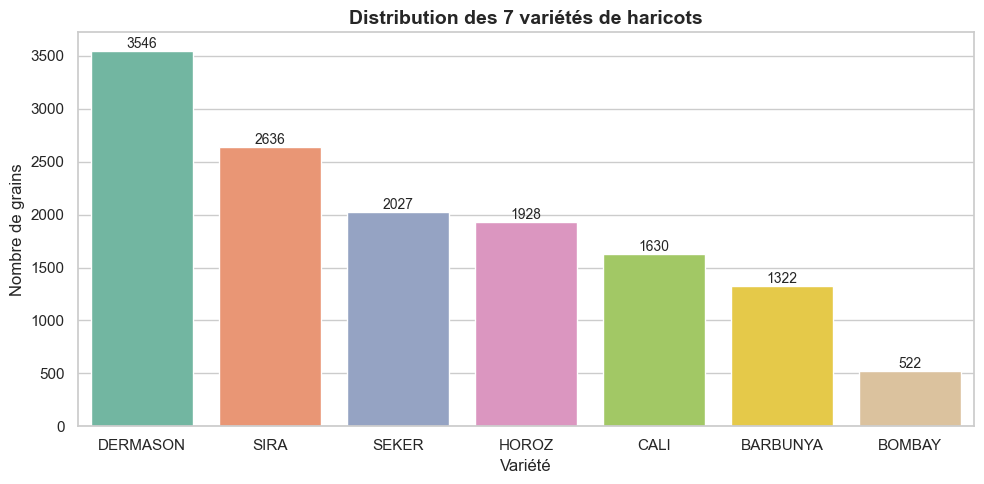

Commentaire : La classe DERMASON est la plus représentée (3546 grains),
tandis que BOMBAY est la moins fréquente (522 grains). Le dataset est
légèrement déséquilibré mais reste exploitable pour la classification.


In [12]:
# ============================================================
# 05_exploratory_data_analysis
# ============================================================

# --- 5.1 Distribution des classes ---
plt.figure(figsize=(10, 5))
ordre = df['Class'].value_counts().index
sns.countplot(data=df, x='Class', order=ordre, palette='Set2')
plt.title("Distribution des 7 variétés de haricots", fontsize=14, fontweight='bold')
plt.xlabel("Variété")
plt.ylabel("Nombre de grains")
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig("fig_01_distribution_classes.png", dpi=150)
plt.show()
print("Commentaire : La classe DERMASON est la plus représentée (3546 grains),")
print("tandis que BOMBAY est la moins fréquente (522 grains). Le dataset est")
print("légèrement déséquilibré mais reste exploitable pour la classification.")

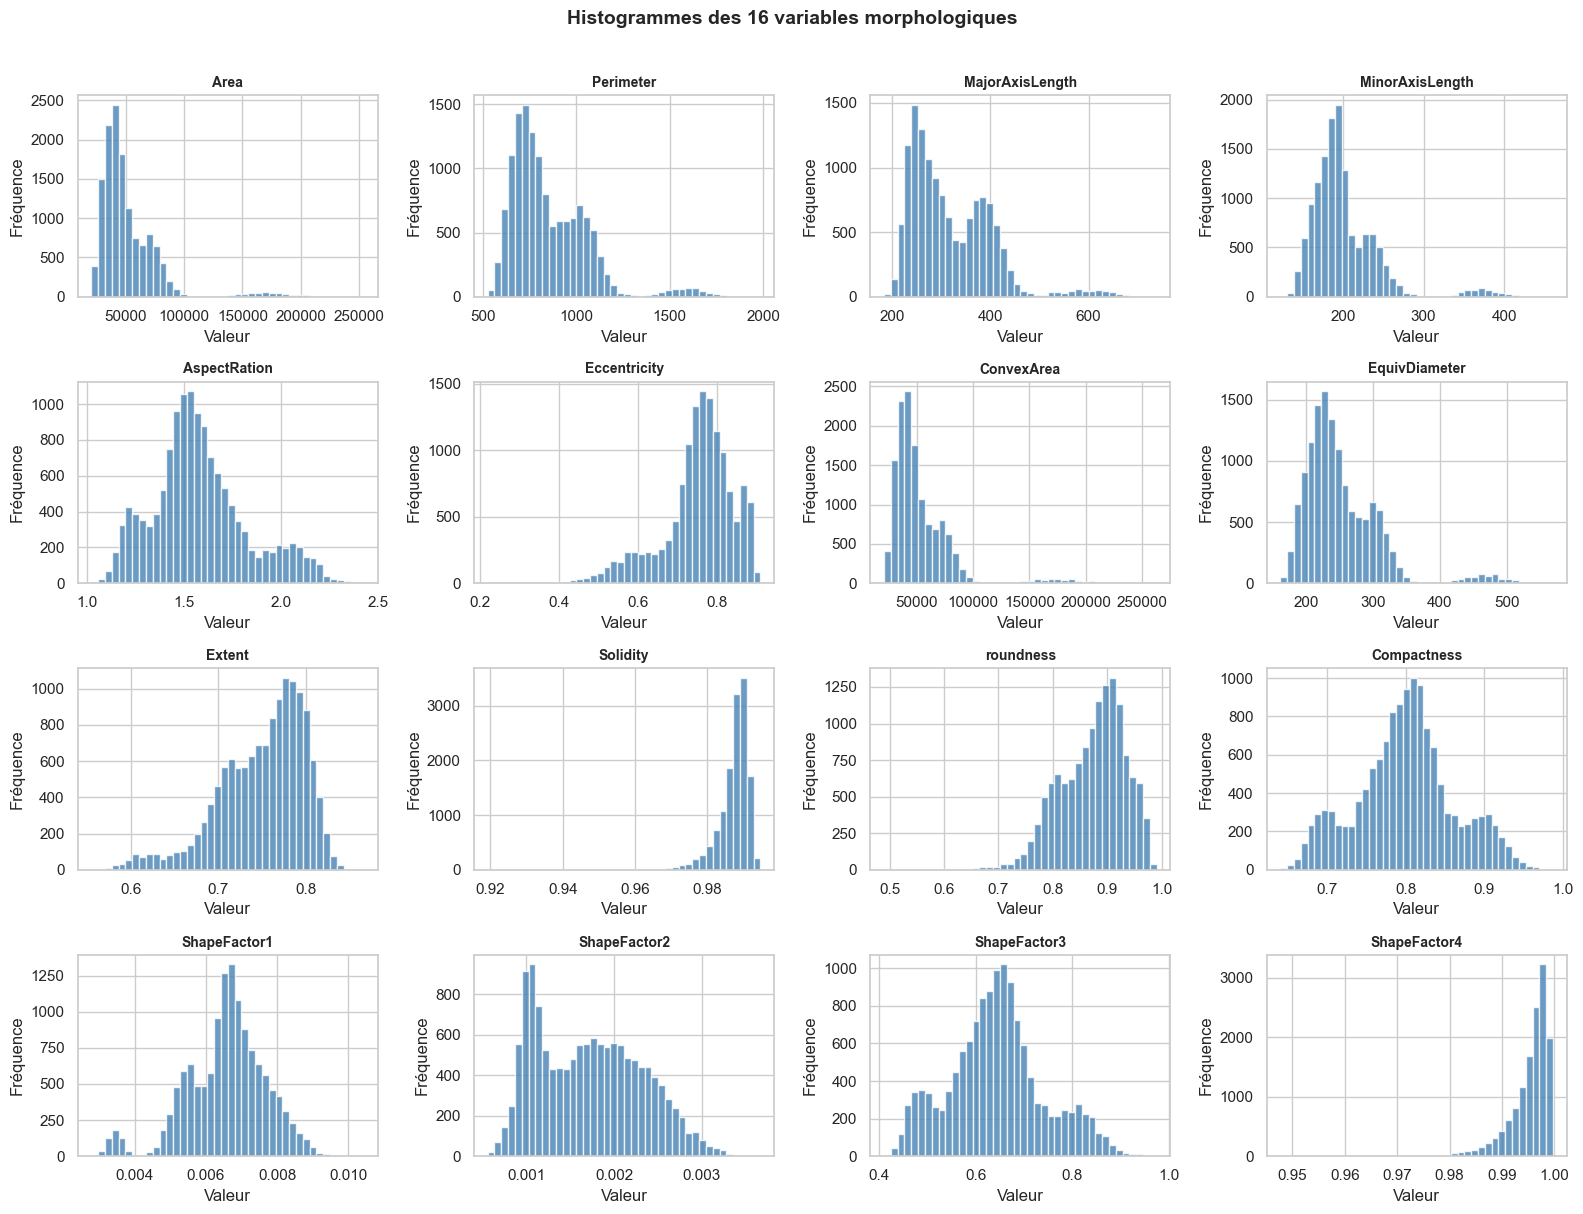

Commentaire : La plupart des variables morphologiques suivent une
distribution approximativement normale ou légèrement asymétrique.
Les variables Area et ConvexArea montrent une forte dispersion,
reflétant les différences de taille entre les variétés.


In [13]:
# --- 5.2 Histogrammes des 16 variables numériques ---
variables_num = df.drop(columns=['Class'])

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(variables_num.columns):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Valeur")
    axes[i].set_ylabel("Fréquence")

plt.suptitle("Histogrammes des 16 variables morphologiques", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("fig_02_histogrammes.png", dpi=150)
plt.show()

print("Commentaire : La plupart des variables morphologiques suivent une")
print("distribution approximativement normale ou légèrement asymétrique.")
print("Les variables Area et ConvexArea montrent une forte dispersion,")
print("reflétant les différences de taille entre les variétés.")

C:\Users\user\AppData\Local\Temp\ipykernel_14552\3162447130.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
C:\Users\user\AppData\Local\Temp\ipykernel_14552\3162447130.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
C:\Users\user\AppData\Local\Temp\ipykernel_14552\3162447130.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
C:\Users\user\AppData\Local\Temp\ipykernel_145

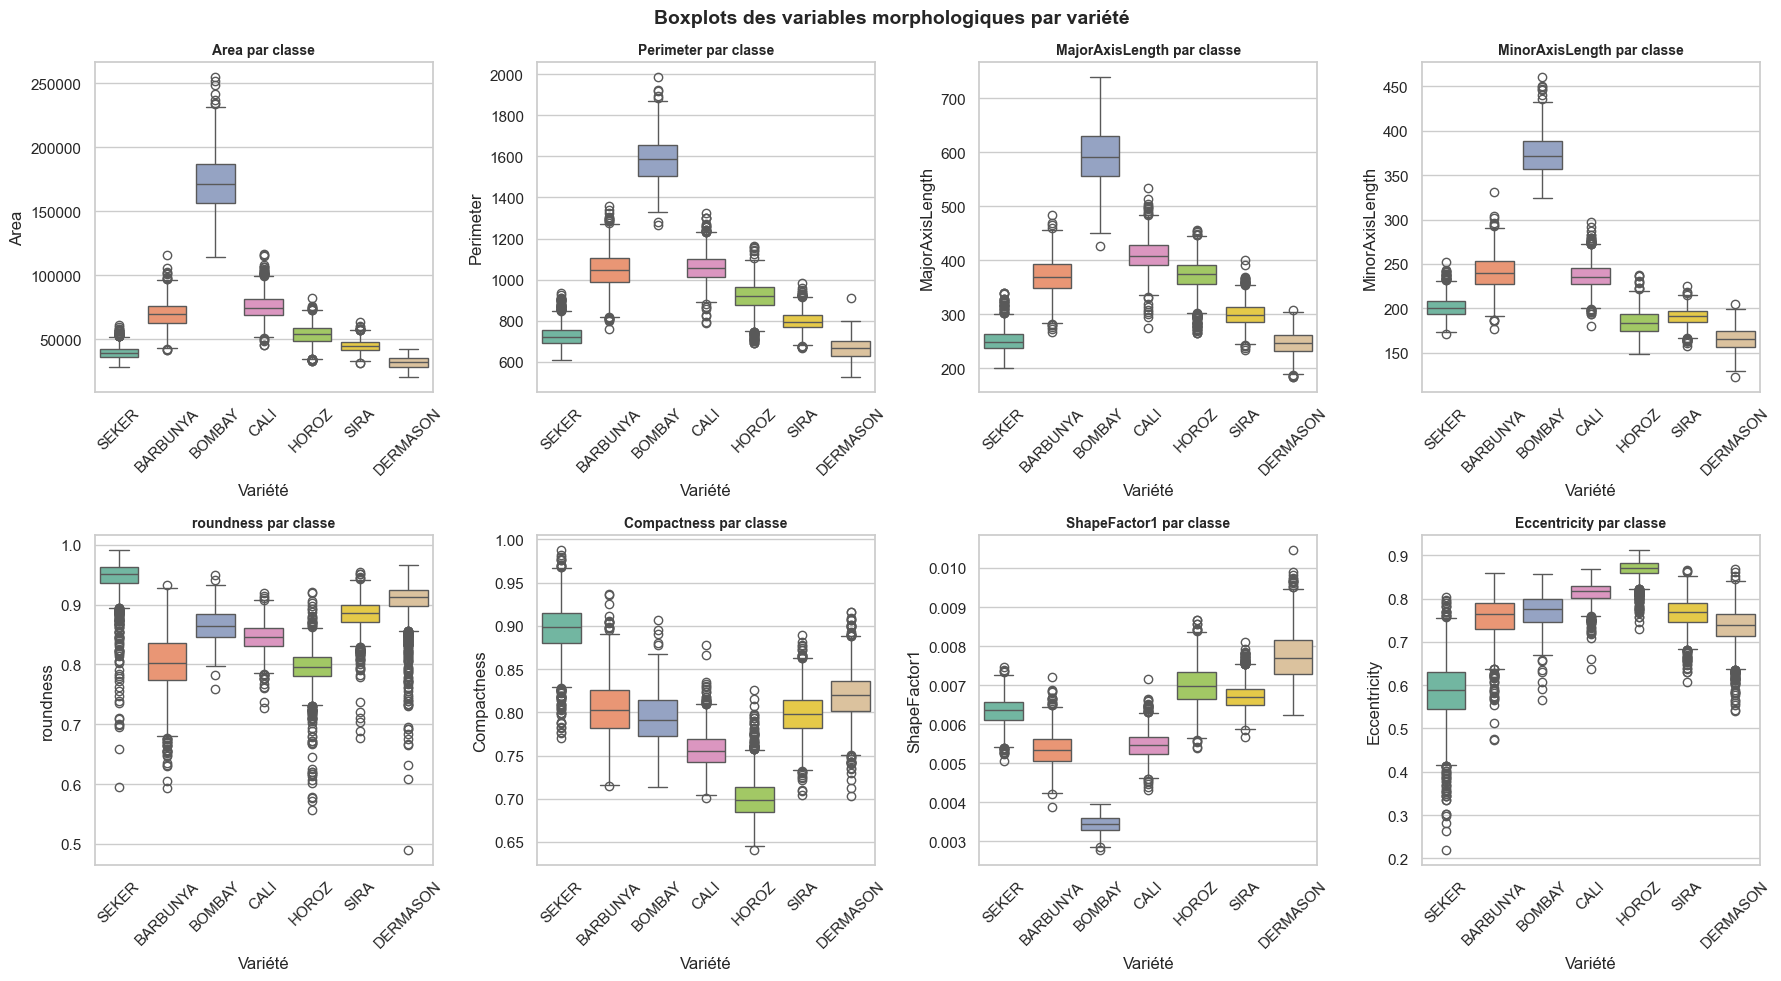

Commentaire : Les boxplots révèlent que BOMBAY se distingue nettement
des autres variétés par des valeurs d'Area et de Perimeter beaucoup
plus élevées. DERMASON et SIRA ont des profils morphologiques proches,
ce qui pourrait poser des difficultés lors de la classification.


In [14]:
# --- 5.3 Boxplots par classe (4 variables les plus discriminantes) ---
vars_boxplot = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                'roundness', 'Compactness', 'ShapeFactor1', 'Eccentricity']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(vars_boxplot):
    sns.boxplot(data=df, x='Class', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f"{col} par classe", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Variété")
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle("Boxplots des variables morphologiques par variété", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_03_boxplots_classe.png", dpi=150)
plt.show()

print("Commentaire : Les boxplots révèlent que BOMBAY se distingue nettement")
print("des autres variétés par des valeurs d'Area et de Perimeter beaucoup")
print("plus élevées. DERMASON et SIRA ont des profils morphologiques proches,")
print("ce qui pourrait poser des difficultés lors de la classification.")

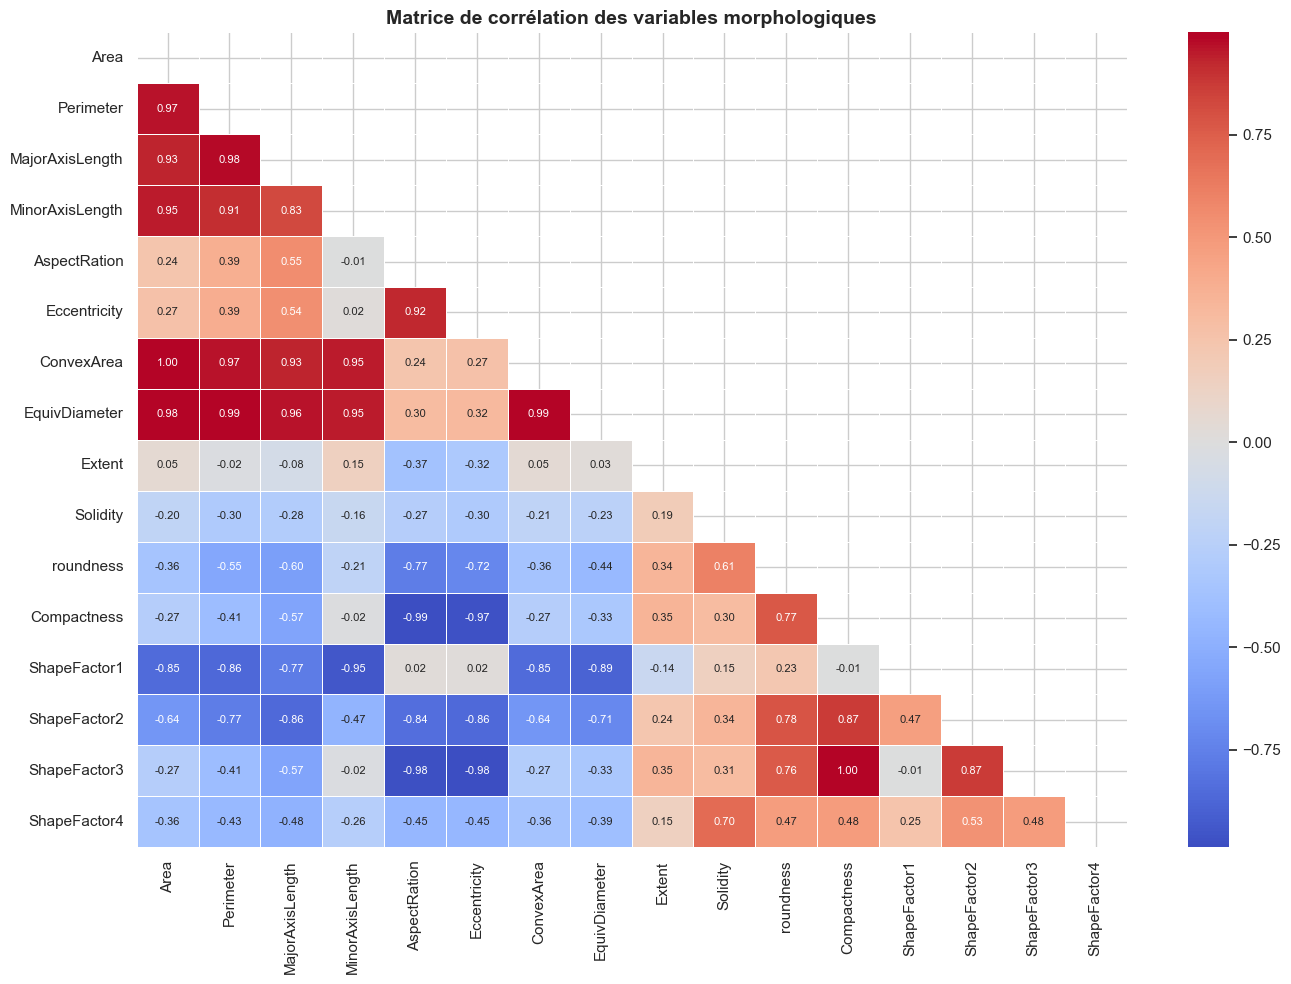

Commentaire : De fortes corrélations positives existent entre Area,
Perimeter, MajorAxisLength, MinorAxisLength et ConvexArea (r > 0.95),
ce qui indique une redondance d'information liée à la taille du grain.
À l'inverse, roundness et Eccentricity sont fortement négativement
corrélées (-0.93), car un grain rond a une faible excentricité.


In [15]:
# --- 5.4 Matrice de corrélation ---
plt.figure(figsize=(14, 10))
corr_matrix = df.drop(columns=['Class']).corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={"size": 8})
plt.title("Matrice de corrélation des variables morphologiques",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig_04_correlation.png", dpi=150)
plt.show()

print("Commentaire : De fortes corrélations positives existent entre Area,")
print("Perimeter, MajorAxisLength, MinorAxisLength et ConvexArea (r > 0.95),")
print("ce qui indique une redondance d'information liée à la taille du grain.")
print("À l'inverse, roundness et Eccentricity sont fortement négativement")
print("corrélées (-0.93), car un grain rond a une faible excentricité.")

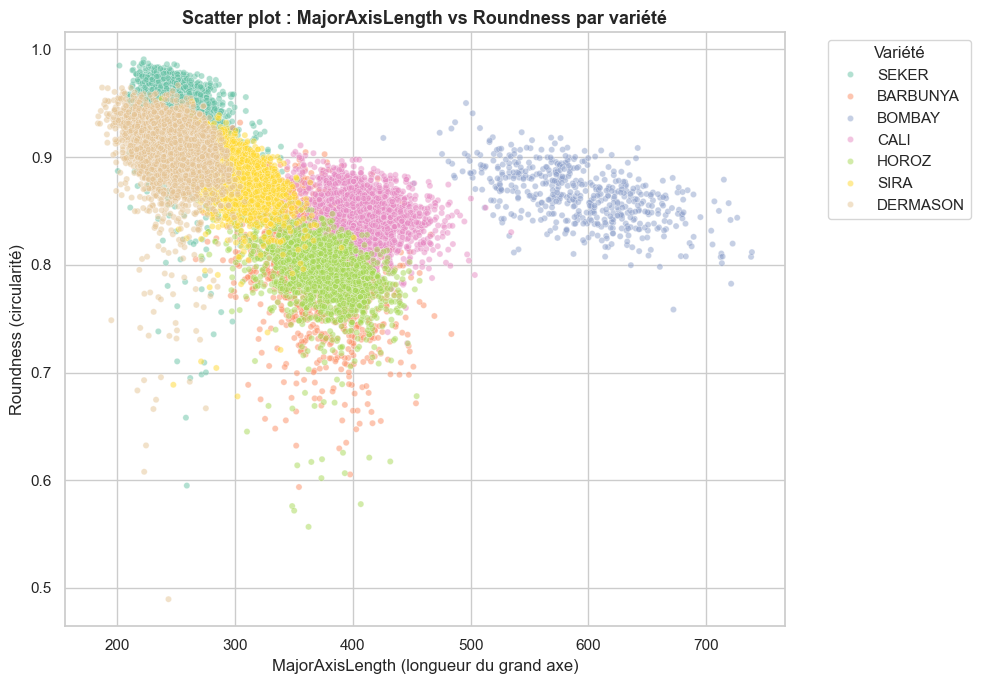

Commentaire : Ce scatter plot montre que BOMBAY forme un groupe isolé
avec de grandes valeurs de MajorAxisLength et une faible roundness.
DERMASON et SIRA se chevauchent dans la zone centrale, confirmant
leur proximité morphologique observée dans les boxplots.


In [16]:
# --- 5.5 Scatter plot : deux variables discriminantes ---
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='MajorAxisLength', y='roundness',
                hue='Class', palette='Set2', alpha=0.5, s=20)
plt.title("Scatter plot : MajorAxisLength vs Roundness par variété",
          fontsize=13, fontweight='bold')
plt.xlabel("MajorAxisLength (longueur du grand axe)")
plt.ylabel("Roundness (circularité)")
plt.legend(title="Variété", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("fig_05_scatter.png", dpi=150)
plt.show()

print("Commentaire : Ce scatter plot montre que BOMBAY forme un groupe isolé")
print("avec de grandes valeurs de MajorAxisLength et une faible roundness.")
print("DERMASON et SIRA se chevauchent dans la zone centrale, confirmant")
print("leur proximité morphologique observée dans les boxplots.")